## Multi-modal RAG

<div style="border:1px solid #ccc; border-radius:6px; padding:12px;">

<br>
<b>About</b><br><br>

This notebook is derived from the following notebook, with modifications and extensions: https://github.com/AI-Engineering-bootcamp/ai-eng-nbs-public/blob/master/multi-modal-rag-202504.ipynb
</div>

## Intro

This notebook builds a multi-modal RAG pipeline for documents that mix text, tables, and images (e.g., PDFs with charts). 

Approach:
- Extract text, tables, and images from a PDF using Unstructured.
- Generate text summaries for images/tables using a multi-modal LLM (GPT-4V).
- Store raw content in a multi-vector retriever (Chroma) indexed by these summaries.
- Retrieve relevant text/images for a query and pass them to GPT-4V to synthesize the final answer.

<br>

## From Text-Only to Multimodal RAG

Many documents mix content types — text, tables, and images (charts, diagrams, screenshots). Yet most RAG pipelines only index text, so anything captured visually is effectively invisible to retrieval.

<br>

With multimodal LLMs now common — both proprietary (e.g., GPT, Claude, Gemini) and open-weight (e.g., Qwen-VL, LLaMA Vision, Pixtral) — there are a few ways to bring images into RAG:


**Option 1: Embed everything natively**

* Use multimodal embeddings to embed images and text into the same vector space
* Retrieve both via similarity search
* Pass raw images and text chunks to a multimodal LLM for answer synthesis

**Option 2: Summarize images to text**

* Use a multimodal LLM to generate text summaries of images
* Embed and retrieve only the text summaries
* Pass text chunks to a (text-only) LLM for answer synthesis

**Option 3: Summarize for retrieval, keep raw for synthesis**

* Use a multimodal LLM to generate text summaries of images
* Embed and retrieve the *summaries*, but keep a reference to the original raw image
* Pass the raw images (and text/tables) to a multimodal LLM for answer synthesis


<br>


Here's a comparison:

- **Option 1** skips summarization entirely, embedding images and text directly. It's the most direct approach, but its quality depends on the multimodal embedding model, which can still lag behind text embeddings for nuanced similarity search.
- **Option 2** summarizes images into text and retrieves only the summaries. It's simple and works even with text-only LLMs at the synthesis stage, but it discards the raw image — so any detail lost in the summary is gone for good.
- **Option 3** also summarizes images, but keeps a reference to the raw image alongside each summary. Retrieval is driven by the summary, while the original image is still handed to the LLM at synthesis time — avoiding the tradeoff Option 2 makes.

This notebook implements **Option 3**: the best of both worlds, since retrieval quality benefits from clean text summaries, while answer synthesis benefits from the full visual detail of the original image.


* We use [Unstructured](https://unstructured.io/) to parse text, tables, and images out of PDFs
* We use a **multi-vector retriever** with a vector store to index summaries while storing raw content separately
* We use a multimodal LLM both to generate image summaries and to synthesize the final answer



![ss_mm_rag.png](https://education-team-2020.s3.eu-west-1.amazonaws.com/ai-eng/ss_mm_rag.png)



<br>

## IMPORTANT: Packages

In addition to the below pip packages, you will also need `poppler` ([installation instructions](https://pdf2image.readthedocs.io/en/latest/installation.html)) and `tesseract` ([installation instructions](https://tesseract-ocr.github.io/tessdoc/Installation.html)) in your system.

<br>

- → On a mac, open a terminal and run this command: `brew install tesseract poppler`

<br>

Note: This course was developed and tested with:
- Tesseract 5.5.3
- Poppler 26.07.0

<br>


In [1]:
# ! pip install "langchain==0.2.17" "langchain-core==0.2.43" "langchain-openai==0.1.25" "langchain-community==0.2.19" "langchain-experimental==0.0.65" "openai==1.109.1" "chromadb==1.5.9" # pinned to a mutually-compatible, verified-working set

In [2]:
# ! pip install "unstructured[all-docs]==0.25.0" "pillow==12.3.0" "pydantic==2.13.4" "lxml==6.1.1" "matplotlib==3.11.1" "chromadb==1.5.9" "tiktoken==0.13.0"

In [3]:
# Make sure that tesseract and poppler are in the path
# For Mac users with homebrew:
import os
bin_path = '/opt/homebrew/bin/'
os.environ['PATH'] = bin_path + ':' + os.getenv('PATH')

<br>

## Data Loading

### Partition PDF tables, text, and images
  
Our input data will be a PDF version from a [popular blog](https://cloudedjudgement.substack.com/p/clouded-judgement-111023) by Jamin Ball.

This is a great use-case because much of the information is captured in images (of tables or charts).

We use `Unstructured` to partition it (see [blog post](https://blog.langchain.dev/semi-structured-multi-modal-rag/)).

The PDF is available at `sample_files/example_pdf_document.pdf`

---

Alternative: skip `Unstructured` extraction and use pre-extracted objects from documents

In the `sample_files` folder you can find a sub-set of the extracted images and pdf.

If you want to use the provided folder, then simply opt for a [pdf loader](https://python.langchain.com/docs/modules/data_connection/document_loaders/pdf) for the document:

```
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader(path + fname)
docs = loader.load()
tables = [] # Ignore w/ basic pdf loader
texts = [d.page_content for d in docs]
```

In [4]:
from langchain_text_splitters import CharacterTextSplitter
from unstructured.partition.pdf import partition_pdf


# Extract elements from PDF
# This may take a few minutes, be patient. No GPU required.
def extract_pdf_elements(path, fname):
    """
    Extract images, tables, and chunk text from a PDF file.
    path: File path, which is used to dump images (.jpg)
    fname: File name
    """
    return partition_pdf(
        filename=path + fname,
        strategy="hi_res",
        infer_table_structure=True,
        chunking_strategy="by_title",
        max_characters=4000,
        new_after_n_chars=3800,
        combine_text_under_n_chars=2000,
        extract_image_block_types=["Image"],
        extract_image_block_output_dir=path,
    )


# Categorize elements by type
def categorize_elements(raw_pdf_elements):
    """
    Categorize extracted elements from a PDF into tables and texts.
    raw_pdf_elements: List of unstructured.documents.elements
    """
    tables = []
    texts = []
    for element in raw_pdf_elements:
        if "unstructured.documents.elements.Table" in str(type(element)):
            tables.append(str(element))
        elif "unstructured.documents.elements.CompositeElement" in str(type(element)):
            texts.append(str(element))
    return texts, tables


# File path
fpath = "sample_files/"
fname = "example_pdf_document.pdf"

# Get elements
raw_pdf_elements = extract_pdf_elements(fpath, fname)

# Get text, tables
texts, tables = categorize_elements(raw_pdf_elements)

# Optional: Enforce a specific token size for texts
text_splitter = CharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=4000, chunk_overlap=0
)
joined_texts = " ".join(texts)
texts_4k_token = text_splitter.split_text(joined_texts)

/Users/luis/Desktop/ironhack_june26/1_ai_eng_lectures/.venv/langchain-v0.2.x/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
C

In [23]:
print(texts)
print(tables)

['Clouded Judgement 11.10.23 - OpenAI Updat + Datadog Gives the All-Clear?\n\nJAMIN BALL\n\nNOV 10, 2023\n\n42 2 4\n\nEvery week I’ll provide updates on the latest trends in cloud software companies\n\nFollow along to stay up to date!\n\nType your email... Subscribe\n\nOpenAI Updates\n\nOpenAI had their big developer day this week, and I wanted to call out two key announcements (and trends): increasing context windows and decreasing costs.\n\nWhen I think about the monetization of AI (and which “layers” monetize first) I’v always thought it would follow the below order, with each layer lagging the one t\n\ncomes before it.\n\n1. Raw silicon (chips like Nvidia bought in large quantities to build out infra to\n\nservice upcoming demand).\n\n2. Model providers (OpenAI, Anthropic, etc as companies start building out AI\n\n3. Hyperscalers (AWS, Azure, GCP as companies look for cloud GPUs who aren\n\nbuilding out their own data centers)\n\n4. Infra (Data layer, orchestration, monitoring, ops

<br>

## Multi-vector retriever

We now have three types of raw content extracted from the PDF: text chunks, tables, and (soon) images. None of these are embedded yet.

In this section we'll prepare the pieces we need to build our multi-vector retriever (introduced earlier):

1. **Step 1 — Generate text and table summaries**: short, retrieval-friendly summaries of each text chunk and table, produced by an LLM.
2. **Step 2 — Generate image summaries**: a text description of each image, produced by a multimodal LLM.
3. **Step 3 — Index summaries, store raw content separately**: embed the summaries for similarity search, while keeping the original raw text/table/image alongside them so the full, unabridged content is what actually gets passed to the LLM at answer time.

We start below with Step 1: summarizing the text chunks and tables.

<br>

### Step 1: Text and Table summaries

We will use GPT-4 to produce table and, optionally, text summaries.

Text summaries are advised if using large chunk sizes (e.g., as set above, we use 4k token chunks).

Summaries are used to retrieve raw tables and / or raw chunks of text.

In [6]:
from dotenv import find_dotenv, load_dotenv

_ = load_dotenv(find_dotenv())

In [7]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI


# Generate summaries of text elements
def generate_text_summaries(texts, tables, summarize_texts=False):
    """
    Summarize text elements
    texts: List of str
    tables: List of str
    summarize_texts: Bool to summarize texts
    """

    # Prompt
    prompt_text = """You are an assistant tasked with summarizing tables and text for retrieval. \
    These summaries will be embedded and used to retrieve the raw text or table elements. \
    Give a concise summary of the table or text that is well optimized for retrieval. Table or text: {element} """
    prompt = ChatPromptTemplate.from_template(prompt_text)

    # Text summary chain
    model = ChatOpenAI(temperature=0, model="gpt-4")
    summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

    # Initialize empty summaries
    text_summaries = []
    table_summaries = []

    # Apply to text if texts are provided and summarization is requested
    if texts and summarize_texts:
        text_summaries = summarize_chain.batch(texts, {"max_concurrency": 5})
    elif texts:
        text_summaries = texts

    # Apply to tables if tables are provided
    if tables:
        table_summaries = summarize_chain.batch(tables, {"max_concurrency": 5})

    return text_summaries, table_summaries


# Get text, table summaries
text_summaries, table_summaries = generate_text_summaries(
    texts_4k_token, tables, summarize_texts=True
)

<br>

### Step 2: Image summaries

Now we move on to the images that Unstructured extracted from the PDF (saved as `.jpg` files in `sample_files/`).

For each image, we will:

1. Encode the image file as a base64 string (the format expected by the OpenAI API).
2. Send that base64 image to GPT-4o and ask it to describe the image in a short, retrieval-friendly summary.
3. Collect both the base64 string and its summary, so we have everything ready to index in the next step.

We use GPT-4o here because it's multimodal — unlike the GPT-4 (text-only) model used for the text/table summaries above, GPT-4o can accept images directly as input, per the API docs [here](https://platform.openai.com/docs/guides/vision).

In [8]:
import base64
import os

from langchain_core.messages import HumanMessage


def encode_image(image_path):
    """Getting the base64 string"""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


def image_summarize(img_base64, prompt):
    """Make image summary"""
    chat = ChatOpenAI(model="gpt-4o", max_tokens=1024)

    msg = chat.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
                    },
                ]
            )
        ]
    )
    return msg.content


def generate_img_summaries(path):
    """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    """

    # Store base64 encoded images
    img_base64_list = []

    # Store image summaries
    image_summaries = []

    # Prompt
    prompt = """You are an assistant tasked with summarizing images for retrieval. \
    These summaries will be embedded and used to retrieve the raw image. \
    Give a concise summary of the image that is well optimized for retrieval."""

    # Apply to images
    for img_file in sorted(os.listdir(path)):
        if img_file.endswith(".jpg"):
            img_path = os.path.join(path, img_file)
            base64_image = encode_image(img_path)
            img_base64_list.append(base64_image)
            image_summaries.append(image_summarize(base64_image, prompt))

    return img_base64_list, image_summaries


# Image summaries
img_base64_list, image_summaries = generate_img_summaries(fpath)

<br>

### Step 3: Add to vectorstore

At this point we have, for each piece of content (text chunks, tables, images): the raw content itself, plus a short summary of it. Now we bring it all together into the multi-vector retriever.

For each type of content (texts, tables, images), we will:

1. Generate a unique ID for each item.
2. Embed its **summary** and add it to the `vectorstore` (a Chroma collection) — this is what similarity search actually runs against.
3. Store the matching **raw content** in the `docstore` (an in-memory key-value store), keyed by that same ID.

The two stores are linked by ID: when a summary is matched during retrieval, the retriever uses its ID to look up and return the original raw text, table, or image — never the summary itself. This is what lets us search over concise summaries while still handing the LLM the full, unabridged content at answer time.

See [Multi Vector Retriever](https://python.langchain.com/docs/modules/data_connection/retrievers/multi_vector#summary) for more details.

In [9]:
import uuid

from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain.storage import InMemoryStore
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings


def create_multi_vector_retriever(
    vectorstore, text_summaries, texts, table_summaries, tables, image_summaries, images
):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """

    # Initialize the storage layer
    store = InMemoryStore()
    id_key = "doc_id"

    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=store,
        id_key=id_key,
    )

    # Helper function to add documents to the vectorstore and docstore
    def add_documents(retriever, doc_summaries, doc_contents):
        doc_ids = [str(uuid.uuid4()) for _ in doc_contents]
        summary_docs = [
            Document(page_content=s, metadata={id_key: doc_ids[i]})
            for i, s in enumerate(doc_summaries)
        ]
        retriever.vectorstore.add_documents(summary_docs)
        retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

    # Add texts, tables, and images
    # Check that text_summaries is not empty before adding
    if text_summaries:
        add_documents(retriever, text_summaries, texts)
    # Check that table_summaries is not empty before adding
    if table_summaries:
        add_documents(retriever, table_summaries, tables)
    # Check that image_summaries is not empty before adding
    if image_summaries:
        add_documents(retriever, image_summaries, images)

    return retriever


# The vectorstore to use to index the summaries
vectorstore = Chroma(
    collection_name="mm_rag_cj_blog", embedding_function=OpenAIEmbeddings()
)

# Create retriever
retriever_multi_vector_img = create_multi_vector_retriever(
    vectorstore,
    text_summaries,
    texts,
    table_summaries,
    tables,
    image_summaries,
    img_base64_list,
)

/var/folders/x1/00w2xr_j197gk698c1ljm3300000gn/T/ipykernel_62149/1984908346.py:53: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the langchain-chroma package and should be used instead. To use it run `pip install -U langchain-chroma` and import as `from langchain_chroma import Chroma`.
  vectorstore = Chroma(


<br>

## RAG

### Build the multimodal RAG chain

Our retriever (built above) returns a mix of raw content — some docs will be text/table strings, others will be base64-encoded images — depending on which summary best matched the query. Before we can hand this off to GPT-4o, we need to prepare it correctly.

Below we define the helper functions that turn retrieved docs into a working RAG chain:

* `plt_img_base64` / `looks_like_base64` / `is_image_data`: display a base64 string as an image, and detect whether a given doc is actually image data (vs. plain text).
* `resize_base64_image`: shrink images before sending them to the LLM, since answer quality is sensitive to image size (and large images cost more tokens).
* `split_image_text_types`: given the list of retrieved docs, sort them into two buckets — `images` and `texts` — using the checks above.
* `img_prompt_func`: build the final multimodal prompt, combining the user's question, the retrieved text/tables, and the retrieved images (as `image_url` content blocks) into a single message.
* `multi_modal_rag_chain`: wire it all together into one chain — retrieve docs → split into images/texts → build the prompt → call GPT-4o → parse the response as a string.

In [10]:
import io
import re

from IPython.display import HTML, display
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from PIL import Image


def plt_img_base64(img_base64):
    """Disply base64 encoded string as image"""
    # Create an HTML img tag with the base64 string as the source
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
    # Display the image by rendering the HTML
    display(HTML(image_html))


def looks_like_base64(sb):
    """Check if the string looks like base64"""
    return re.match("^[A-Za-z0-9+/]+[=]{0,2}$", sb) is not None


def is_image_data(b64data):
    """
    Check if the base64 data is an image by looking at the start of the data
    """
    image_signatures = {
        b"\xff\xd8\xff": "jpg",
        b"\x89\x50\x4e\x47\x0d\x0a\x1a\x0a": "png",
        b"\x47\x49\x46\x38": "gif",
        b"\x52\x49\x46\x46": "webp",
    }
    try:
        header = base64.b64decode(b64data)[:8]  # Decode and get the first 8 bytes
        for sig, format in image_signatures.items():
            if header.startswith(sig):
                return True
        return False
    except Exception:
        return False


def resize_base64_image(base64_string, size=(128, 128)):
    """
    Resize an image encoded as a Base64 string
    """
    # Decode the Base64 string
    img_data = base64.b64decode(base64_string)
    img = Image.open(io.BytesIO(img_data))

    # Resize the image
    resized_img = img.resize(size, Image.LANCZOS)

    # Save the resized image to a bytes buffer
    buffered = io.BytesIO()
    resized_img.save(buffered, format=img.format)

    # Encode the resized image to Base64
    return base64.b64encode(buffered.getvalue()).decode("utf-8")


def split_image_text_types(docs):
    """
    Split base64-encoded images and texts
    """
    b64_images = []
    texts = []
    for doc in docs:
        # Check if the document is of type Document and extract page_content if so
        if isinstance(doc, Document):
            doc = doc.page_content
        if looks_like_base64(doc) and is_image_data(doc):
            doc = resize_base64_image(doc, size=(1300, 600))
            b64_images.append(doc)
        else:
            texts.append(doc)
    return {"images": b64_images, "texts": texts}


def img_prompt_func(data_dict):
    """
    Join the context into a single string
    """
    formatted_texts = "\n".join(data_dict["context"]["texts"])
    messages = []

    # Adding image(s) to the messages if present
    if data_dict["context"]["images"]:
        for image in data_dict["context"]["images"]:
            image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
            messages.append(image_message)

    # Adding the text for analysis
    text_message = {
        "type": "text",
        "text": (
            "You are financial analyst tasking with providing investment advice.\n"
            "You will be given a mixed of text, tables, and image(s) usually of charts or graphs.\n"
            "Use this information to provide investment advice related to the user question. \n"
            f"User-provided question: {data_dict['question']}\n\n"
            "Text and / or tables:\n"
            f"{formatted_texts}"
        ),
    }
    messages.append(text_message)
    return [HumanMessage(content=messages)]


def multi_modal_rag_chain(retriever):
    """
    Multi-modal RAG chain
    """

    # Multi-modal LLM
    model = ChatOpenAI(temperature=0, model="gpt-4o", max_tokens=1024)

    # RAG pipeline
    chain = (
        {
            "context": retriever | RunnableLambda(split_image_text_types),
            "question": RunnablePassthrough(),
        }
        | RunnableLambda(img_prompt_func)
        | model
        | StrOutputParser()
    )

    return chain


# Create RAG chain
chain_multimodal_rag = multi_modal_rag_chain(retriever_multi_vector_img)

<br>

### Check

Examine retrieval; we get back images that are relevant to our question.

In [22]:
# Check retrieval
query = "What are the EV / NTM and NTM rev growth for MongoDB, Cloudflare, and Datadog?"
docs = retriever_multi_vector_img.invoke(query, limit=6)

len(docs)

4


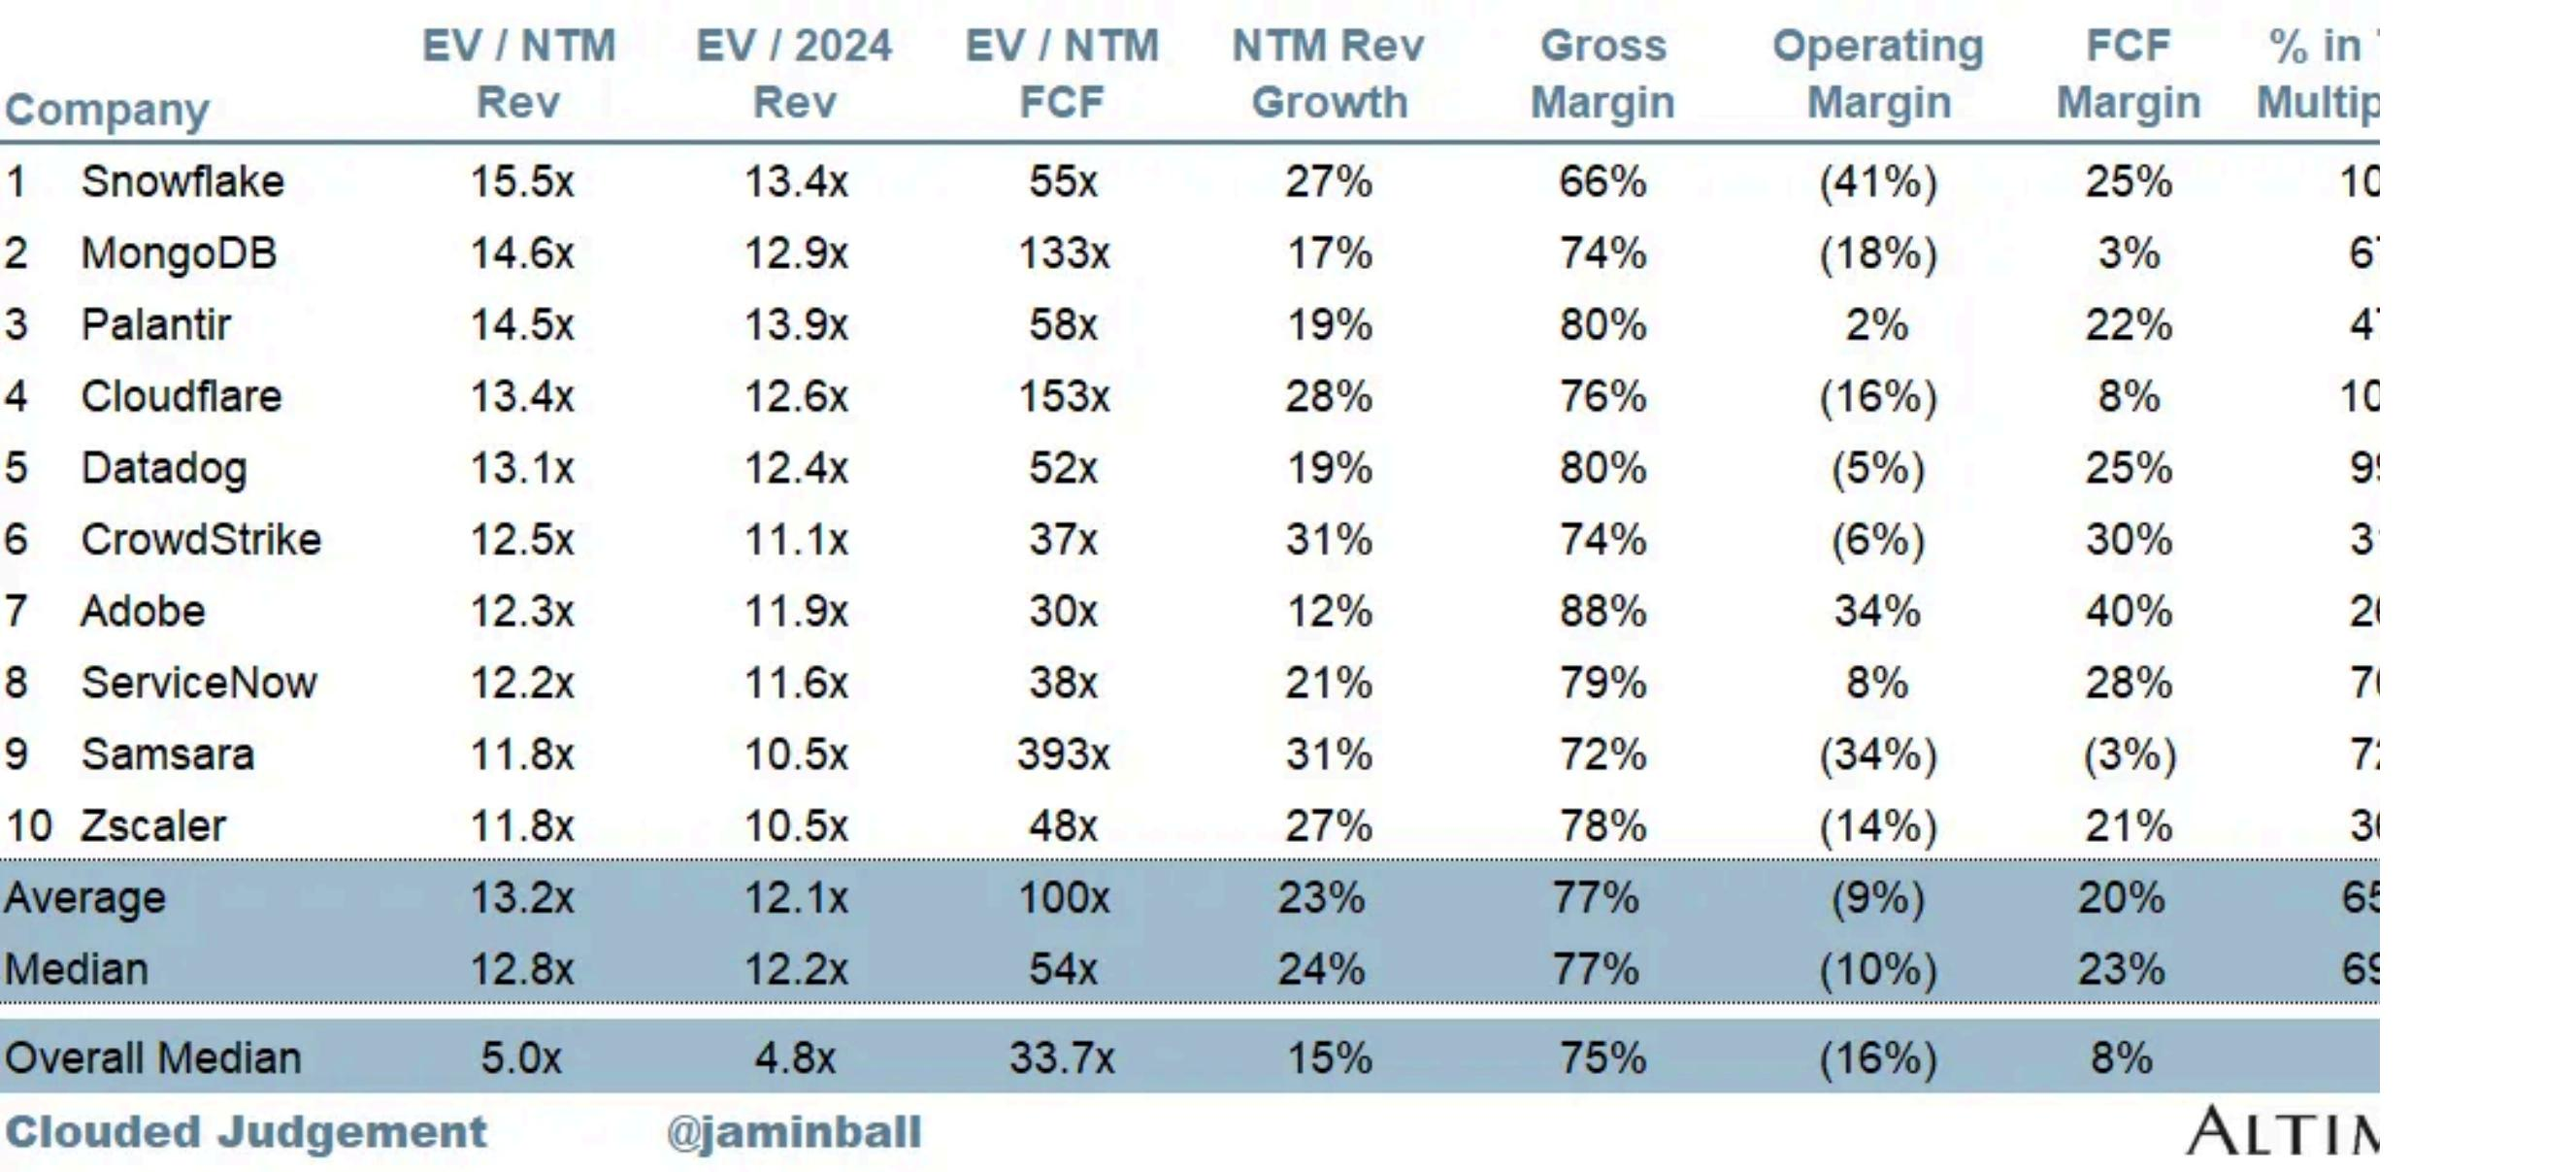

In [21]:
# We get back relevant images
# Note: not every result is guaranteed to be an image - some queries may match
# a text/table chunk instead, so we check before trying to display it as one
doc_idx = 0
if looks_like_base64(docs[doc_idx]) and is_image_data(docs[doc_idx]):
    plt_img_base64(docs[doc_idx])
else:
    print("The top match for this query is a text/table chunk, not an image:\n")
    print(docs[doc_idx])

<br>

### Sanity Check

Why does this work? Let's look back at the image that we stored ...


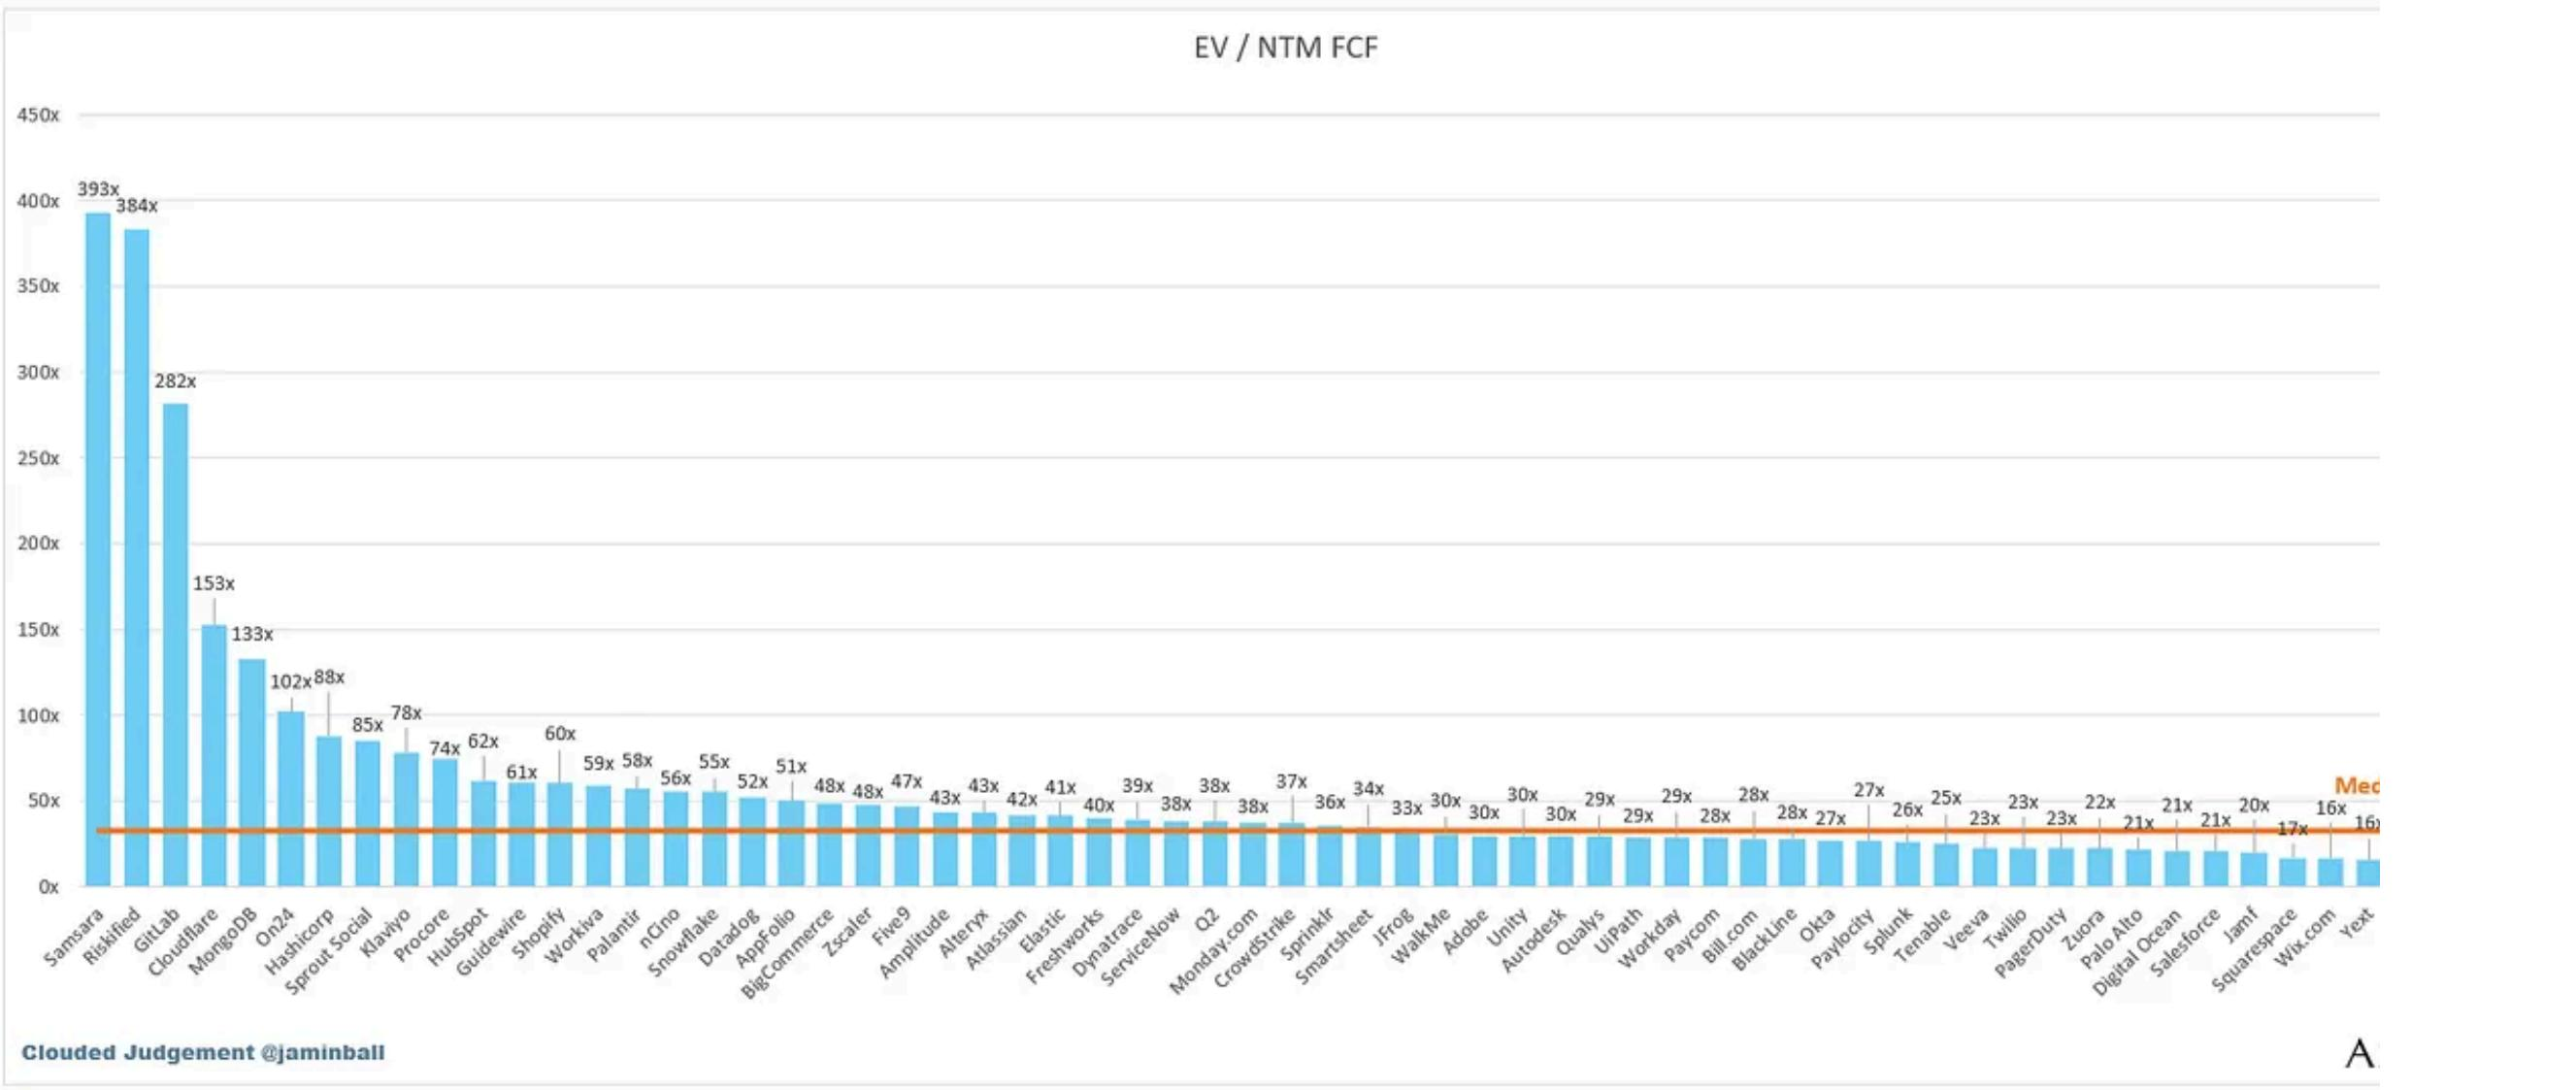

In [15]:
plt_img_base64(img_base64_list[3])

... here is the corresponding summary, which we embedded and used in similarity search.

It's pretty reasonable that this image is indeed retrieved from our `query` based on it's similarity to this summary.

In [16]:
image_summaries[3]

'Bar chart displaying EV/NTM FCF ratios for various companies. Samsara, Riskified, and GitLab have the highest ratios, significantly above others. The chart shows a descending trend from left to right, with a median line marked in orange.'

<br>

### Run the RAG chain

We've now built and sanity-checked every piece: the retriever returns the right raw content, and `chain_multimodal_rag` knows how to turn that content into a multimodal prompt for GPT-4o.

Let's put it all together and run the full chain end-to-end: given our `query`, it will retrieve the relevant text/table/image content, build the prompt, and ask GPT-4o to synthesize a final answer.

In [17]:
# Run RAG chain
chain_multimodal_rag.invoke(query)

'Based on the provided table:\n\n- **MongoDB:**\n  - EV / NTM Revenue: 14.6x\n  - NTM Revenue Growth: 17%\n\n- **Cloudflare:**\n  - EV / NTM Revenue: 13.4x\n  - NTM Revenue Growth: 28%\n\n- **Datadog:**\n  - EV / NTM Revenue: 13.1x\n  - NTM Revenue Growth: 19%\n\nThese metrics indicate that all three companies have relatively high EV/NTM revenue multiples, suggesting they are valued at a premium compared to the overall median of 5.0x. Cloudflare shows the highest revenue growth among the three, which might justify its valuation.'

Here is the trace where we can see what is passed to the LLM.

We can see the traces in somebody's Langsmith account. We will learn more about Langsmith later.
 
* Question 1 [Trace focused on investment advice](https://smith.langchain.com/public/d77b7b52-4128-4772-82a7-c56eb97e8b97/r)
* Question 2 [Trace focused on table extraction](https://smith.langchain.com/public/4624f086-1bd7-4284-9ca9-52fd7e7a4568/r)

For question 1, we can see that we pass 3 images along with a text chunk:

![trace.png](https://education-team-2020.s3.eu-west-1.amazonaws.com/ai-eng/trace.png)

<br>

### Considerations

**Retrieval**
 
* Retrieval is performed based upon similarity to image summaries as well as text chunks.
* This requires some careful consideration because image retrieval can fail if there are competing text chunks.
* To mitigate this, I produce larger (4k token) text chunks and summarize them for retrieval.

**Image Size**

* The quality of answer synthesis appears to be sensitive to image size, [as expected](https://platform.openai.com/docs/guides/vision).
